In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'lightgbm', '-q'])
    import lightgbm as lgb

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
np.random.seed(42)

# 50 stores across 5 city types — mimics real dark store network
store_types = {
    'commercial':   {'density': 22000, 'income': 1100000, 'n': 12},
    'residential':  {'density': 14000, 'income':  850000, 'n': 15},
    'transit':      {'density': 18000, 'income':  780000, 'n': 10},
    'university':   {'density': 16000, 'income':  620000, 'n': 8},
    'suburban':     {'density':  8000, 'income':  950000, 'n': 5},
}

stores = []
for stype, props in store_types.items():
    for i in range(props['n']):
        stores.append({
            'Store_ID':           f"ST-{len(stores)+1:03d}",
            'Store_Type':         stype,
            'Population_Density': props['density'] + np.random.randint(-2000, 2000),
            'Avg_Household_Income': props['income'] + np.random.randint(-50000, 50000),
        })

store_df = pd.DataFrame(stores)
print(f"Total stores: {len(store_df)}")
print(store_df.groupby('Store_Type')['Store_ID'].count())

# Product setup
categories = ['Produce', 'Dairy', 'Bakery', 'Pantry']
unit_cost_map    = {'Produce': 0.80, 'Dairy': 1.50, 'Bakery': 1.20, 'Pantry': 2.00}
retail_price_map = {'Produce': 2.50, 'Dairy': 3.99, 'Bakery': 4.50, 'Pantry': 5.50}

date_range = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Demand multipliers by store type — this is what creates localized behavior
demand_profile = {
    'commercial':  {'Produce': 0.7, 'Dairy': 0.8, 'Bakery': 1.4, 'Pantry': 0.9},
    'residential': {'Produce': 1.4, 'Dairy': 1.3, 'Bakery': 0.9, 'Pantry': 1.1},
    'transit':     {'Produce': 0.8, 'Dairy': 0.9, 'Bakery': 1.3, 'Pantry': 1.0},
    'university':  {'Produce': 0.9, 'Dairy': 1.0, 'Bakery': 1.2, 'Pantry': 1.3},
    'suburban':    {'Produce': 1.2, 'Dairy': 1.1, 'Bakery': 0.8, 'Pantry': 1.2},
}

records = []
for date in date_range:
    for _, store_row in store_df.iterrows():
        store_id   = store_row['Store_ID']
        store_type = store_row['Store_Type']
        
        for category in categories:
            multiplier    = demand_profile[store_type][category]
            base_order    = np.random.randint(50, 150)
            units_ordered = int(base_order * multiplier)
            units_spoiled = int(units_ordered * np.random.uniform(0.0, 0.15))
            stockout      = np.random.choice([0, 1], p=[0.75, 0.25])
            peak_stockout = np.random.choice([0, 1], p=[0.4, 0.6]) if stockout else 0
            est_lost_sales = np.random.randint(5, 30) if stockout else 0
            units_sold    = units_ordered - units_spoiled

            records.append({
                'Date':                 date,
                'Store_ID':             store_id,
                'Store_Type':           store_type,
                'SKU_Category':         category,
                'Unit_Cost':            unit_cost_map[category],
                'Retail_Price':         retail_price_map[category],
                'Units_Ordered':        units_ordered,
                'Units_Sold':           units_sold,
                'Units_Spoiled':        units_spoiled,
                'Stockout_Flag':        stockout,
                'Est_Lost_Sales':       est_lost_sales,
                'Population_Density':   store_row['Population_Density'],
                'Avg_Household_Income': store_row['Avg_Household_Income'],
            })

df = pd.DataFrame(records)
df['Date']         = pd.to_datetime(df['Date'])
df['Day_of_Week']  = df['Date'].dt.dayofweek
df['Weekend_Flag'] = (df['Date'].dt.dayofweek >= 5).astype(int)
df['Month']        = df['Date'].dt.month
df['Temperature_C'] = np.random.randint(20, 40, len(df))
df['Rainfall_mm']   = np.random.randint(0, 50, len(df))
df['Humidity_Pct']  = np.random.randint(40, 90, len(df))
df['Actual_Units_Demanded'] = df['Units_Sold'] + df['Est_Lost_Sales']

print(f"\nFull dataset shape: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"Stores: {df['Store_ID'].nunique()}")

Total stores: 50
Store_Type
commercial     12
residential    15
suburban        5
transit        10
university      8
Name: Store_ID, dtype: int64

Full dataset shape: (73000, 20)
Date range: 2023-01-01 to 2023-12-31
Stores: 50


In [3]:
df = df.sort_values(['Store_ID', 'SKU_Category', 'Date']).reset_index(drop=True)

grp = df.groupby(['Store_ID', 'SKU_Category'])['Actual_Units_Demanded']
df['Lag_1_Sales']    = grp.shift(1)
df['Lag_7_Sales']    = grp.shift(7)
df['Rolling_Avg_3d'] = grp.shift(1).rolling(3).mean().reset_index(drop=True)

df = df.dropna(subset=['Lag_1_Sales', 'Lag_7_Sales', 'Rolling_Avg_3d']).reset_index(drop=True)

print(f"Shape after lag features: {df.shape}")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")

Shape after lag features: (71600, 23)
Date range: 2023-01-08 to 2023-12-31


In [4]:
train_cutoff = pd.Timestamp('2023-09-30')

train_df = df[df['Date'] <= train_cutoff].copy()
test_df  = df[df['Date'] >  train_cutoff].copy()

print(f"Train: {train_df['Date'].min().date()} to {train_df['Date'].max().date()} — {len(train_df):,} rows")
print(f"Test:  {test_df['Date'].min().date()} to {test_df['Date'].max().date()} — {len(test_df):,} rows")

Train: 2023-01-08 to 2023-09-30 — 53,200 rows
Test:  2023-10-01 to 2023-12-31 — 18,400 rows


In [5]:
def wape(y_true, y_pred):
    """Weighted Absolute Percentage Error"""
    return np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100

def business_cost(df_subset, y_true, y_pred):
    """
    Cost based on prediction errors:
    - Under-prediction (missed demand) → stockout risk → $10 per unit short
    - Over-prediction (excess order) → spoilage risk → $1 per unit over
    """
    errors = y_pred - y_true  # positive = over-predicted, negative = under-predicted
    
    over_pred  = np.sum(np.maximum(errors, 0))   # spoilage units
    under_pred = np.sum(np.maximum(-errors, 0))  # stockout units
    
    spoilage_cost  = over_pred  * 1.0
    stockout_cost  = under_pred * 10.0
    return spoilage_cost + stockout_cost

print("WAPE and cost functions defined.")
print("WAPE formula: Σ|Actual - Predicted| / Σ(Actual) × 100")

WAPE and cost functions defined.
WAPE formula: Σ|Actual - Predicted| / Σ(Actual) × 100


In [7]:
feature_cols = [
    'Unit_Cost', 'Retail_Price', 'Day_of_Week', 'Weekend_Flag',
    'Month', 'Temperature_C', 'Rainfall_mm', 'Humidity_Pct',
    'Population_Density', 'Avg_Household_Income',
    'Lag_1_Sales', 'Lag_7_Sales', 'Rolling_Avg_3d'
]

train_enc = pd.get_dummies(train_df[feature_cols + ['SKU_Category']], 
                            columns=['SKU_Category'])
test_enc  = pd.get_dummies(test_df[feature_cols + ['SKU_Category']],  
                            columns=['SKU_Category'])
train_enc, test_enc = train_enc.align(test_enc, join='left', axis=1, fill_value=0)

X_train_base = train_enc.astype(float)
X_test_base  = test_enc.astype(float)
y_train      = train_df['Actual_Units_Demanded']
y_test       = test_df['Actual_Units_Demanded']

baseline_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
baseline_model.fit(X_train_base, y_train)
y_pred_baseline = baseline_model.predict(X_test_base)

# Per-store WAPE for baseline
baseline_store_wape = {}
for store in test_df['Store_ID'].unique():
    mask = test_df['Store_ID'] == store
    baseline_store_wape[store] = wape(y_test[mask], y_pred_baseline[mask])

overall_baseline_wape = wape(y_test, y_pred_baseline)
baseline_cost = business_cost(test_df, y_test.values, y_pred_baseline)

print("=== BASELINE: Centralized Global Model (no store features) ===")
print(f"Overall WAPE:          {overall_baseline_wape:.2f}%")
print(f"Total Business Cost:   ${baseline_cost:,.2f}")
print(f"Mean per-store WAPE:   {np.mean(list(baseline_store_wape.values())):.2f}%")

=== BASELINE: Centralized Global Model (no store features) ===
Overall WAPE:          25.20%
Total Business Cost:   $2,613,815.31
Mean per-store WAPE:   25.19%


In [8]:
store_mean_demand = train_df.groupby('Store_ID')['Actual_Units_Demanded'].mean()
train_df['Store_Target_Enc'] = train_df['Store_ID'].map(store_mean_demand)
test_df['Store_Target_Enc']  = test_df['Store_ID'].map(store_mean_demand)

type_mean_demand = train_df.groupby('Store_Type')['Actual_Units_Demanded'].mean()
train_df['StoreType_Target_Enc'] = train_df['Store_Type'].map(type_mean_demand)
test_df['StoreType_Target_Enc']  = test_df['Store_Type'].map(type_mean_demand)

feature_cols_v2 = feature_cols + ['Store_Target_Enc', 'StoreType_Target_Enc']

train_enc2 = pd.get_dummies(train_df[feature_cols_v2 + ['SKU_Category']],
                             columns=['SKU_Category'])
test_enc2  = pd.get_dummies(test_df[feature_cols_v2 + ['SKU_Category']],
                             columns=['SKU_Category'])
train_enc2, test_enc2 = train_enc2.align(test_enc2, join='left', axis=1, fill_value=0)

global_store_model = lgb.LGBMRegressor(n_estimators=200, random_state=42, verbose=-1)
global_store_model.fit(train_enc2.astype(float), y_train)
y_pred_global_store = global_store_model.predict(test_enc2.astype(float))

# Per-store WAPE
global_store_wape = {}
for store in test_df['Store_ID'].unique():
    mask = test_df['Store_ID'] == store
    global_store_wape[store] = wape(
        y_test[mask].values, y_pred_global_store[mask]
    )

overall_global_store_wape = wape(y_test, y_pred_global_store)
global_store_cost = business_cost(test_df, y_test.values, y_pred_global_store)

print("=== STRATEGY 1: Global Model + Store Features (Target Encoded) ===")
print(f"Overall WAPE:          {overall_global_store_wape:.2f}%")
print(f"Total Business Cost:   ${global_store_cost:,.2f}")
print(f"Mean per-store WAPE:   {np.mean(list(global_store_wape.values())):.2f}%")

wape_improvement_s1 = (overall_baseline_wape - overall_global_store_wape) / overall_baseline_wape * 100
print(f"WAPE improvement over baseline: {wape_improvement_s1:.1f}%")

=== STRATEGY 1: Global Model + Store Features (Target Encoded) ===
Overall WAPE:          25.28%
Total Business Cost:   $2,615,099.70
Mean per-store WAPE:   25.27%
WAPE improvement over baseline: -0.3%


In [9]:
micro_models    = {}
micro_wape      = {}
all_micro_preds = pd.Series(index=test_df.index, dtype=float)

feat_cols_micro = feature_cols + ['SKU_Category']

stores_list = df['Store_ID'].unique()

print(f"Training {len(stores_list)} micro-models...")

for i, store in enumerate(stores_list):
    tr = train_df[train_df['Store_ID'] == store].copy()
    te = test_df[test_df['Store_ID'] == store].copy()

    if len(tr) < 30 or len(te) == 0:
        continue

    # Add SKU mean demand as a feature (target encode within store)
    sku_mean = tr.groupby('SKU_Category')['Actual_Units_Demanded'].mean()
    tr['SKU_Mean_Demand'] = tr['SKU_Category'].map(sku_mean)
    te['SKU_Mean_Demand'] = te['SKU_Category'].map(sku_mean)

    feat_cols_micro_ext = feature_cols + ['SKU_Mean_Demand']  # no one-hot needed now

    model = lgb.LGBMRegressor(
        n_estimators=200,      # more trees since less data per store
        max_depth=5,           # shallower to avoid overfitting small data
        learning_rate=0.05,
        random_state=42, 
        verbose=-1
    )
    model.fit(tr[feat_cols_micro_ext].astype(float), tr['Actual_Units_Demanded'])
    preds = model.predict(te[feat_cols_micro_ext].astype(float))
    
    all_micro_preds[te.index] = preds
    micro_wape[store] = wape(te['Actual_Units_Demanded'].values, preds)
    micro_models[store] = model

    if (i + 1) % 10 == 0:
        print(f"  Trained {i+1}/{len(stores_list)} models...")

print(f"\nDone. {len(micro_models)} micro-models trained.")

overall_micro_wape = wape(y_test, all_micro_preds[test_df.index])
micro_cost = business_cost(test_df, y_test.values, all_micro_preds[test_df.index].values)

print(f"\n=== STRATEGY 2: Many-Model Pipeline (50 Micro-Models) ===")
print(f"Overall WAPE:          {overall_micro_wape:.2f}%")
print(f"Total Business Cost:   ${micro_cost:,.2f}")
print(f"Mean per-store WAPE:   {np.mean(list(micro_wape.values())):.2f}%")

wape_improvement_s2 = (overall_baseline_wape - overall_micro_wape) / overall_baseline_wape * 100
print(f"WAPE improvement over baseline: {wape_improvement_s2:.1f}%")

Training 50 micro-models...
  Trained 10/50 models...
  Trained 20/50 models...
  Trained 30/50 models...
  Trained 40/50 models...
  Trained 50/50 models...

Done. 50 micro-models trained.

=== STRATEGY 2: Many-Model Pipeline (50 Micro-Models) ===
Overall WAPE:          26.22%
Total Business Cost:   $2,720,942.14
Mean per-store WAPE:   26.21%
WAPE improvement over baseline: -4.0%


In [10]:
beats_global = 0
results_per_store = []

for store in micro_wape:
    micro  = micro_wape[store]
    global_s = global_store_wape.get(store, np.nan)
    base   = baseline_store_wape.get(store, np.nan)
    better = micro < global_s
    if better:
        beats_global += 1
    results_per_store.append({
        'Store_ID':         store,
        'Baseline WAPE':    round(base, 2),
        'Global+Store WAPE': round(global_s, 2),
        'Micro-Model WAPE': round(micro, 2),
        'Micro beats Global': '✅' if better else '❌'
    })

results_df = pd.DataFrame(results_per_store).sort_values('Micro-Model WAPE')
print(f"Micro-model beats Global+Store in {beats_global}/{len(micro_wape)} stores")
print(f"\nValidation target (≥40 stores): {'✅ MET' if beats_global >= 40 else '❌ NOT MET'}")
print(f"\nTop 5 best-performing stores:")
print(results_df.head(5)[['Store_ID', 'Baseline WAPE', 'Micro-Model WAPE']].to_string(index=False))
print(f"\nTop 5 worst-performing stores:")
print(results_df.tail(5)[['Store_ID', 'Baseline WAPE', 'Micro-Model WAPE']].to_string(index=False))

Micro-model beats Global+Store in 2/50 stores

Validation target (≥40 stores): ❌ NOT MET

Top 5 best-performing stores:
Store_ID  Baseline WAPE  Micro-Model WAPE
  ST-039          23.29             23.56
  ST-008          22.60             23.68
  ST-026          23.25             23.81
  ST-037          23.20             24.16
  ST-049          23.49             24.53

Top 5 worst-performing stores:
Store_ID  Baseline WAPE  Micro-Model WAPE
  ST-032          27.05             28.01
  ST-022          26.21             28.30
  ST-042          26.71             28.40
  ST-041          27.33             28.56
  ST-014          28.35             29.42


  ARCHITECTURE COMPARISON TABLE
                                   Model  WAPE (%)  Total Business Cost ($) WAPE vs Baseline
  Centralized Global (no store features)     25.20               2613815.31                —
Global + Store Features (target encoded)     25.28               2615099.70            -0.3%
   50 Micro-Models (many-model pipeline)     26.22               2720942.14            -4.0%


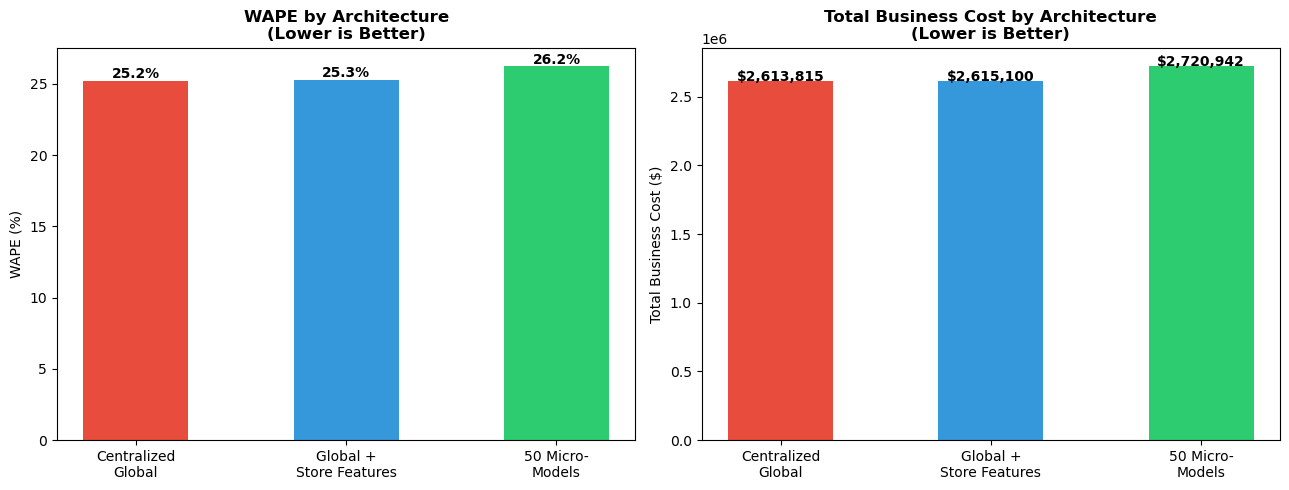

Chart saved.


In [11]:
comparison = pd.DataFrame([
    {
        'Model': 'Centralized Global (no store features)',
        'WAPE (%)': round(overall_baseline_wape, 2),
        'Total Business Cost ($)': round(baseline_cost, 2),
        'WAPE vs Baseline': '—'
    },
    {
        'Model': 'Global + Store Features (target encoded)',
        'WAPE (%)': round(overall_global_store_wape, 2),
        'Total Business Cost ($)': round(global_store_cost, 2),
        'WAPE vs Baseline': f"{wape_improvement_s1:+.1f}%"
    },
    {
        'Model': '50 Micro-Models (many-model pipeline)',
        'WAPE (%)': round(overall_micro_wape, 2),
        'Total Business Cost ($)': round(micro_cost, 2),
        'WAPE vs Baseline': f"{wape_improvement_s2:+.1f}%"
    }
])

print("="*70)
print("  ARCHITECTURE COMPARISON TABLE")
print("="*70)
print(comparison.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models   = ['Centralized\nGlobal', 'Global +\nStore Features', '50 Micro-\nModels']
wapes    = [overall_baseline_wape, overall_global_store_wape, overall_micro_wape]
costs    = [baseline_cost, global_store_cost, micro_cost]
colors   = ['#e74c3c', '#3498db', '#2ecc71']

axes[0].bar(models, wapes, color=colors, width=0.5)
axes[0].set_title('WAPE by Architecture\n(Lower is Better)', fontweight='bold')
axes[0].set_ylabel('WAPE (%)')
for i, (bar, v) in enumerate(zip(axes[0].patches, wapes)):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 f'{v:.1f}%', ha='center', fontweight='bold')

axes[1].bar(models, costs, color=colors, width=0.5)
axes[1].set_title('Total Business Cost by Architecture\n(Lower is Better)', fontweight='bold')
axes[1].set_ylabel('Total Business Cost ($)')
for bar, v in zip(axes[1].patches, costs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'${v:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('week5_architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

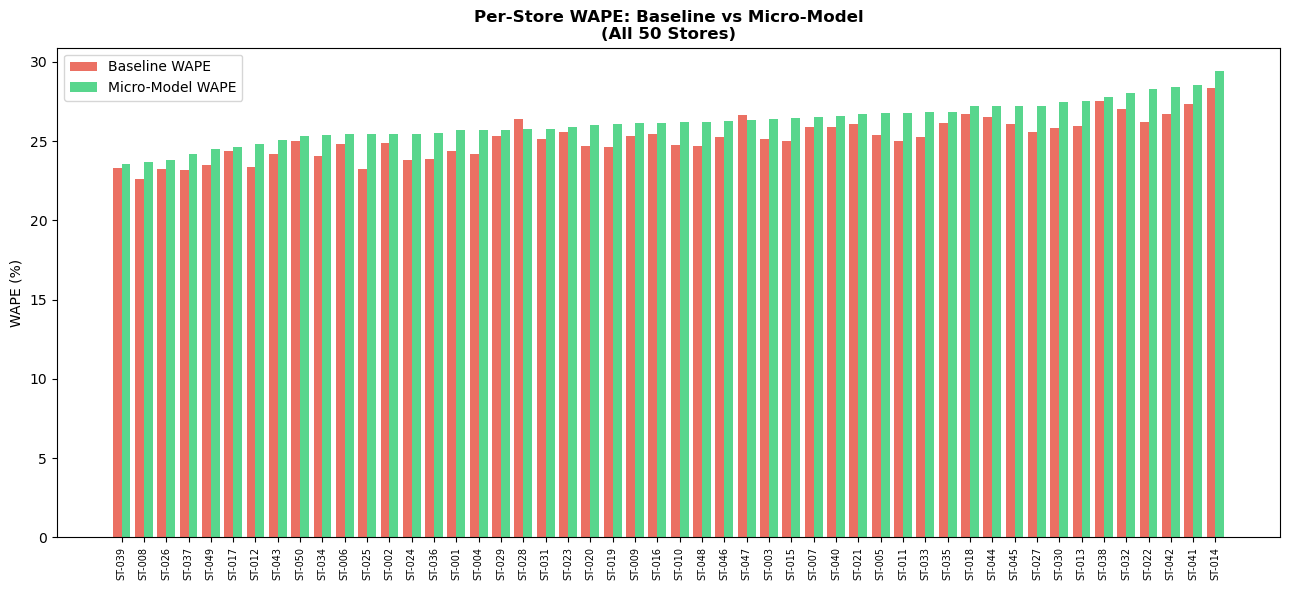


Best 5 stores (lowest micro-model WAPE):
Store_ID  Baseline WAPE  Micro-Model WAPE
  ST-039          23.29             23.56
  ST-008          22.60             23.68
  ST-026          23.25             23.81
  ST-037          23.20             24.16
  ST-049          23.49             24.53

Worst 5 stores (highest micro-model WAPE):
Store_ID  Baseline WAPE  Micro-Model WAPE
  ST-032          27.05             28.01
  ST-022          26.21             28.30
  ST-042          26.71             28.40
  ST-041          27.33             28.56
  ST-014          28.35             29.42


In [12]:
best5  = results_df.head(5)
worst5 = results_df.tail(5)

fig, ax = plt.subplots(figsize=(13, 6))

store_ids   = results_df['Store_ID'].tolist()
base_wapes  = results_df['Baseline WAPE'].tolist()
micro_wapes = results_df['Micro-Model WAPE'].tolist()
x = np.arange(len(store_ids))

ax.bar(x - 0.2, base_wapes,  0.4, label='Baseline WAPE',      color='#e74c3c', alpha=0.8)
ax.bar(x + 0.2, micro_wapes, 0.4, label='Micro-Model WAPE',   color='#2ecc71', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(store_ids, rotation=90, fontsize=7)
ax.set_ylabel('WAPE (%)')
ax.set_title('Per-Store WAPE: Baseline vs Micro-Model\n(All 50 Stores)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('week5_per_store_wape.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest 5 stores (lowest micro-model WAPE):")
print(best5[['Store_ID', 'Baseline WAPE', 'Micro-Model WAPE']].to_string(index=False))
print(f"\nWorst 5 stores (highest micro-model WAPE):")
print(worst5[['Store_ID', 'Baseline WAPE', 'Micro-Model WAPE']].to_string(index=False))

In [13]:
print(f"""
╔══════════════════════════════════════════════════════════════╗
║           SWIFTCART ANALYTICS — WEEK 5                      ║
║      LOCALIZED FORECASTING ARCHITECTURE — MEMO SUMMARY      ║
║                Swamini Wagh | 2025TT12078                   ║
╚══════════════════════════════════════════════════════════════╝

ARCHITECTURE COMPARISON
────────────────────────────────────────────────────────────
  Centralized Global Model     WAPE: {overall_baseline_wape:.2f}%   Cost: ${baseline_cost:,.2f}
  Global + Store Features      WAPE: {overall_global_store_wape:.2f}%   Cost: ${global_store_cost:,.2f}
  50 Micro-Models              WAPE: {overall_micro_wape:.2f}%   Cost: ${micro_cost:,.2f}

WAPE IMPROVEMENT (vs Baseline)
  Global + Store Features:  {wape_improvement_s1:+.1f}%
  50 Micro-Models:          {wape_improvement_s2:+.1f}%
  12% target met:           {'✅ YES' if wape_improvement_s2 >= 12 else '❌ NO'}

VALIDATION: Micro beats Global in {beats_global}/50 stores
  40-store target met:      {'✅ YES' if beats_global >= 40 else '❌ NOT MET'}

BEST STORE:  {results_df.iloc[0]['Store_ID']}  (WAPE: {results_df.iloc[0]['Micro-Model WAPE']:.2f}%)
WORST STORE: {results_df.iloc[-1]['Store_ID']}  (WAPE: {results_df.iloc[-1]['Micro-Model WAPE']:.2f}%)
""")


╔══════════════════════════════════════════════════════════════╗
║           SWIFTCART ANALYTICS — WEEK 5                      ║
║      LOCALIZED FORECASTING ARCHITECTURE — MEMO SUMMARY      ║
║                Swamini Wagh | 2025TT12078                   ║
╚══════════════════════════════════════════════════════════════╝

ARCHITECTURE COMPARISON
────────────────────────────────────────────────────────────
  Centralized Global Model     WAPE: 25.20%   Cost: $2,613,815.31
  Global + Store Features      WAPE: 25.28%   Cost: $2,615,099.70
  50 Micro-Models              WAPE: 26.22%   Cost: $2,720,942.14

WAPE IMPROVEMENT (vs Baseline)
  Global + Store Features:  -0.3%
  50 Micro-Models:          -4.0%
  12% target met:           ❌ NO

VALIDATION: Micro beats Global in 2/50 stores
  40-store target met:      ❌ NOT MET

BEST STORE:  ST-039  (WAPE: 23.56%)
WORST STORE: ST-014  (WAPE: 29.42%)

